LOAD DATA

In [1]:
import pandas as pd

# load data
url_skj = "https://raw.githubusercontent.com/danangtric/PJJ_Data_Analytics_2026/refs/heads/Coba2/2.%20SKJ%20JF%20Perluasan.csv"
url_pelatihan = "https://raw.githubusercontent.com/danangtric/PJJ_Data_Analytics_2026/refs/heads/Coba2/3.%20Katalog%20Pelatihan%202018-2024%20(Puspa).csv"

skj = pd.read_csv(url_skj)
pelatihan = pd.read_csv(url_pelatihan, sep=';')

In [2]:
pelatihan = pelatihan.reset_index(drop=True)

pelatihan['id_pelatihan'] = pelatihan.index.map(lambda x: f"PEL-{x+1:04d}")

In [3]:
skj = skj.reset_index(drop=True)

skj['id_skj'] = skj.index.map(lambda x: f"SKJ-{x+1:04d}")

In [4]:
display(skj.head())

,nama_skj,id_skj
0,Advokasi Kebijakan Perpajakan,SKJ-0001
1,Analisis Data,SKJ-0002
2,Analisis Hasil Pengawasan,SKJ-0003
3,Analisis Hukum Internasional,SKJ-0004
4,Analisis Kebijakan Publik di Bidang Keuangan N...,SKJ-0005


In [5]:
display(pelatihan.head())

,nama_pelatihan,penyelenggara,tahun,id_pelatihan
0,Diklat Fungsional Pemeriksa Dasar,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0001
1,Diklat Teknis Substantif Spesialisasi Pemeriks...,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0002
2,DTS Perpajakan Menengah,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0003
3,DTSS Account Representative Dasar,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0004
4,DTSS Analis IDLP Dasar,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0005


In [6]:
print("Kolom Pelatihan:", pelatihan.columns)
print("Kolom SKJ:", skj.columns)

Kolom Pelatihan: Index(['nama_pelatihan', 'penyelenggara', 'tahun', 'id_pelatihan'], dtype='object')
Kolom SKJ: Index(['nama_skj', 'id_skj'], dtype='object')


In [7]:
col_pelatihan = 'nama_pelatihan'
col_skj = 'nama_skj'

DATA PREPARATION

In [8]:
import re

stop_words_katalog = {
    'pelatihan', 'jarak', 'jauh', 'e', 'learning', 'elearning',
    'diklat', 'df', 'dtsd', 'dts', 'dtss', 'training',
    'excecutive', 'sharing', 'session', 'fgd',
    'focus', 'group', 'discussion', 'in', 'house',
    'kemenkeu', 'corporate', 'university', 'corpu', 'kcoc',
    'open','access','class', 'lokakarya', 'microlearning',
    'blended', 'pjj', 'seminar', 'workshop','seminar digital'
    'uji', 'kompetensi', 'teknis',
    'of', 'trainers', 'tot', 'dan', 'di', 'ke', 'dari',
    'untuk', 'pada', 'dalam', 'yang',
    'level', 'tingkat', 'nasional',
    'angkatan', 'tahun', 'batch',
    'program', 'studi', 'bimtek', 'sosialisasi','webinar'
}

def clean_text(text):
    text = str(text).lower()

    # hapus pola batch/angkatan/tahun + angka
    text = re.sub(r'\b(batch|angkatan|tahun)\s*\d+\b', '', text)

    # normalisasi simbol
    text = re.sub(r'[-_/]', ' ', text)

    # hapus karakter non huruf & angka
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # hapus angka yang berdiri sendiri
    text = re.sub(r'\b\d+\b', '', text)

    # rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    # stopword removal
    words = text.split()
    words = [w for w in words if w not in stop_words_katalog]

    return ' '.join(words)

In [9]:
pelatihan['clean'] = pelatihan['nama_pelatihan'].apply(clean_text)
skj['clean'] = skj['nama_skj'].apply(clean_text)

In [10]:
pelatihan[['nama_pelatihan','clean']].sample(10)

,nama_pelatihan,clean
416,Pelatihan Teknis Pajak Dasar,pajak dasar
62,E-Learning Pengantar E-Audit Perpajakan,pengantar audit perpajakan
247,Pelatihan Jarak Jauh Fungsional Asisten Penyul...,fungsional asisten penyuluh pajak
58,E-learning Pembekalan Secondment: Proses Bisni...,pembekalan secondment proses bisnis perpajakan
369,Pelatihan Master Trainer Aplikasi Sistem Inti ...,master trainer aplikasi sistem inti administra...
46,E-Learning Hukum Pajak Dasar (Seri),hukum pajak dasar seri
82,E-Learning Pengawasan atas DJP: Pengenalan Pro...,pengawasan atas djp pengenalan proses bisnis t...
305,Pelatihan Jarak Jauh Pemeriksaan Bukti Permula...,pemeriksaan bukti permulaan ii
74,E-Learning Pengawasan atas DJP: Pengenalan Pro...,pengawasan atas djp pengenalan proses bisnis t...
213,Pelatihan Fungsional Penilai Pajak Dasar,fungsional penilai pajak dasar


In [11]:
skj[['nama_skj','clean']].head()

,nama_skj,clean
0,Advokasi Kebijakan Perpajakan,advokasi kebijakan perpajakan
1,Analisis Data,analisis data
2,Analisis Hasil Pengawasan,analisis hasil pengawasan
3,Analisis Hukum Internasional,analisis hukum internasional
4,Analisis Kebijakan Publik di Bidang Keuangan N...,analisis kebijakan publik bidang keuangan negara


MODELING

In [12]:
!pip install transformers torch

In [13]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
labels = skj['clean'].tolist()

In [15]:
def map_zero_shot(text, labels):
    """
    text: input clean text
    labels: list clean SKJ labels
    """
    result = classifier(
        text,
        candidate_labels=labels,
        multi_label=True
    )

    labels_sorted = result['labels']
    scores_sorted = result['scores']

    # 🔥 RULE LOGIC sesuai request
    if scores_sorted[0] >= 0.9:
        n = 1
    elif scores_sorted[0] >= 0.4:
        n = 2
    else:
        n = 3

    output = []
    for i in range(min(n, len(labels_sorted))):  # aman kalau jumlah label < n
        output.append({
            'kompetensi': labels_sorted[i],
            'skor': scores_sorted[i]
        })

    return output

In [16]:
from tqdm import tqdm

results = []

for i in tqdm(range(len(pelatihan))):
    # pake text yang sudah di-clean + stopword removed
    text_clean = pelatihan.loc[i, 'clean']
    text_raw = pelatihan.loc[i, 'nama_pelatihan']  # tetap simpan untuk reference

    mapped = map_zero_shot(text_clean, labels)

    for rank, item in enumerate(mapped):
        results.append({
            'id_pelatihan': pelatihan.loc[i, 'id_pelatihan'],
            'nama_pelatihan': text_raw,   # tampilkan nama asli di output
            'rank': rank + 1,
            'kompetensi': item['kompetensi'],
            'skor': item['skor']
        })

100%|██████████| 509/509 [06:14<00:00,  1.36it/s]


In [17]:
import pandas as pd

mapping_zs = pd.DataFrame(results)
mapping_zs.head()

,id_pelatihan,nama_pelatihan,rank,kompetensi,skor
0,PEL-0001,Diklat Fungsional Pemeriksa Dasar,1,dukungan kegiatan investigasi,0.248954
1,PEL-0001,Diklat Fungsional Pemeriksa Dasar,2,pengelolaan hubungan dengan pemangku kepenting...,0.237517
2,PEL-0001,Diklat Fungsional Pemeriksa Dasar,3,ekstensifikasi,0.189066
3,PEL-0002,Diklat Teknis Substantif Spesialisasi Pemeriks...,1,pemeriksaan pajak,0.927849
4,PEL-0003,DTS Perpajakan Menengah,1,pemeriksaan pajak,0.897087


In [18]:
final_output = mapping_zs.groupby(
    ['id_pelatihan','nama_pelatihan']
).agg({
    'kompetensi': list,
    'skor': list
}).reset_index()

In [19]:
# final mapping
final_output.to_excel('mapping_final.xlsx', index=False)

# download
from google.colab import files
files.download('mapping_final.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EVALUASI

In [20]:
url_manual = "https://raw.githubusercontent.com/danangtric/PJJ_Data_Analytics_2026/refs/heads/main/4.%20Data%20training%20(pemetaan%20manual).csv"

manual = pd.read_csv(url_manual, sep=";")
manual.head()

,nama_pelatihan,kompetensi_1,kompetensi_2,kompetensi_3,kompetensi_4,kompetensi_5,kompetensi_6,kompetensi_7
0,E-Learning Analisis Laporan Keuangan dan Surat...,Analisis Kepatuhan Wajib Pajak,Analisis Potensi Pajak,Analisis Profil Risiko Wajib Pajak,Profiling Wajib Pajak,NaN,NaN,NaN
1,E-Learning Analisis Laporan Keuangan dan Surat...,Analisis Kepatuhan Wajib Pajak,Analisis Potensi Pajak,Analisis Profil Risiko Wajib Pajak,Profiling Wajib Pajak,NaN,NaN,NaN
2,E-Learning Pajak Dasar,Analisis Kepatuhan Wajib Pajak,Analisis Potensi Pajak,Analisis Profil Risiko Wajib Pajak,Penanganan Keberatan-Non Keberatan,Penanganan Perkara,Profiling Wajib Pajak,NaN
3,E-learning Penagihan Pajak Daerah (Open Access...,Pelaksanaan Tindakan Penagihan Pajak,Penatausahaan Penagihan Pajak,NaN,NaN,NaN,NaN,NaN
4,E-Learning Pengantar E-Audit Perpajakan,Pemeriksaan Pajak,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
print(manual.columns.tolist())

['nama_pelatihan', 'kompetensi_1', 'kompetensi_2', 'kompetensi_3', 'kompetensi_4', 'kompetensi_5', 'kompetensi_6', 'kompetensi_7']


In [22]:
# Ambil semua kolom kompetensi manual
kompetensi_cols = ['kompetensi_1','kompetensi_2','kompetensi_3',
                   'kompetensi_4','kompetensi_5','kompetensi_6','kompetensi_7']

# Gabungkan jadi list, hilangkan nilai kosong / NaN, lowercase
manual['manual_labels'] = manual[kompetensi_cols].apply(
    lambda row: [str(label).strip().lower() for label in row if pd.notna(label) and str(label).strip() != ''],
    axis=1
)

# Lihat hasil
manual[['nama_pelatihan','manual_labels']].head()

,nama_pelatihan,manual_labels
0,E-Learning Analisis Laporan Keuangan dan Surat...,"[analisis kepatuhan wajib pajak, analisis pote..."
1,E-Learning Analisis Laporan Keuangan dan Surat...,"[analisis kepatuhan wajib pajak, analisis pote..."
2,E-Learning Pajak Dasar,"[analisis kepatuhan wajib pajak, analisis pote..."
3,E-learning Penagihan Pajak Daerah (Open Access...,"[pelaksanaan tindakan penagihan pajak, penatau..."
4,E-Learning Pengantar E-Audit Perpajakan,[pemeriksaan pajak]


In [23]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.6 MB/s eta 0:00:00


In [24]:
from rapidfuzz import fuzz
import pandas as pd

# --- 1️⃣ Persiapan manual ---
kompetensi_cols = ['kompetensi_1','kompetensi_2','kompetensi_3',
                   'kompetensi_4','kompetensi_5','kompetensi_6','kompetensi_7']

manual['manual_labels'] = manual[kompetensi_cols].apply(
    lambda row: [str(label).strip().lower()
                 for label in row
                 if pd.notna(label) and str(label).strip() != ''],
    axis=1
)

# --- 2️⃣ Persiapan model ---
mapping_zs['kompetensi_clean'] = mapping_zs['kompetensi'].apply(lambda x: x.lower().strip())
model_top3 = mapping_zs.groupby('nama_pelatihan').agg({'kompetensi_clean': list}).reset_index()

# --- 3️⃣ Merge manual & model ---
eval_df = model_top3.merge(manual[['nama_pelatihan','manual_labels']], on='nama_pelatihan')

# --- 4️⃣ Fungsi token set ratio (lebih fleksibel) ---
def fuzzy_token_set_score(model_labels, manual_labels, threshold=60):
    match_count = 0
    for m in model_labels:
        for r in manual_labels:
            if fuzz.token_set_ratio(m, r) >= threshold:
                match_count += 1
                break
    return match_count / max(len(model_labels), len(manual_labels))

# --- 5️⃣ Fungsi token-level Jaccard ---
def token_jaccard(model_labels, manual_labels):
    model_tokens = set(" ".join(model_labels).split())
    manual_tokens = set(" ".join(manual_labels).split())
    return len(model_tokens & manual_tokens) / len(model_tokens | manual_tokens)

# --- 6️⃣ Hitung skor ---
eval_df['fuzzy_token_set'] = eval_df.apply(
    lambda row: fuzzy_token_set_score(row['kompetensi_clean'], row['manual_labels'], threshold=60), axis=1)

eval_df['token_jaccard'] = eval_df.apply(
    lambda row: token_jaccard(row['kompetensi_clean'], row['manual_labels']), axis=1)

# --- 7️⃣ Lihat hasil ---
eval_df[['nama_pelatihan','kompetensi_clean','manual_labels','fuzzy_token_set','token_jaccard']]

,nama_pelatihan,kompetensi_clean,manual_labels,fuzzy_token_set,token_jaccard
0,E-Learning Analisis Laporan Keuangan dan Surat...,[analisis data],"[analisis kepatuhan wajib pajak, analisis pote...",0.25,0.111111
1,E-Learning Analisis Laporan Keuangan dan Surat...,[analisis data],"[analisis kepatuhan wajib pajak, analisis pote...",0.25,0.111111
2,E-Learning Pajak Dasar,"[penyidikan perpajakan, penyusunan kebijakan p...","[analisis kepatuhan wajib pajak, analisis pote...",0.00,0.000000
3,E-Learning Pengantar E-Audit Perpajakan,"[dukungan kegiatan investigasi, analisis kepat...",[pemeriksaan pajak],0.00,0.125000
4,E-Learning Pengawasan atas DJP: Pengenalan Pro...,"[penyidikan perpajakan, pengelolaan hubungan d...","[analisis potensi pajak, analisis profil risik...",0.00,0.000000
...,...,...,...,...,...
105,Pelatihan Teknis Pengumpulan Data dan/atau Inf...,[ekstensifikasi],[intelijen perpajakan],0.00,0.000000
106,Seminar Proposal Kajian Akademis KEWENANGAN DI...,"[analisis potensi wajib pajak, pelaksanaan tin...","[pelaksanaan tindakan penagihan pajak, penatau...",0.50,0.500000
107,Training of Trainer E-Audit Perpajakan,"[dukungan kegiatan investigasi, pemeriksaan pa...",[pemeriksaan pajak],0.50,0.400000
108,Training of Trainers (ToT) Teknik Pengamatan,"[intelijen perpajakan, advokasi kebijakan perp...",[intelijen perpajakan],1.00,0.500000


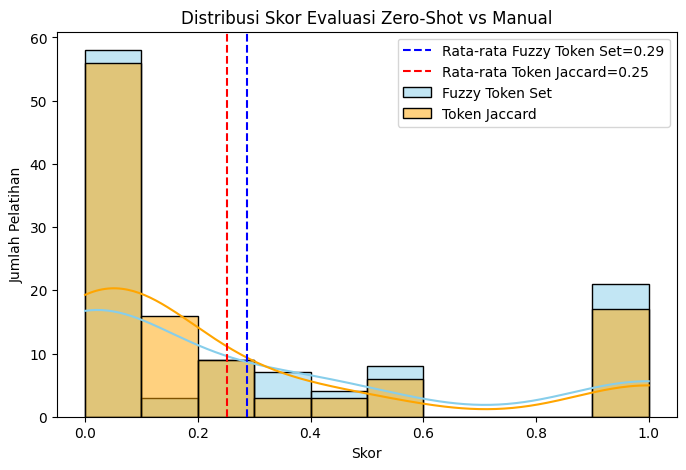

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(eval_df['fuzzy_token_set'], bins=10, kde=True, color='skyblue', label='Fuzzy Token Set')
sns.histplot(eval_df['token_jaccard'], bins=10, kde=True, color='orange', label='Token Jaccard', alpha=0.5)
plt.axvline(avg_fuzzy_token_set, color='blue', linestyle='--', label=f'Rata-rata Fuzzy Token Set={avg_fuzzy_token_set:.2f}')
plt.axvline(avg_token_jaccard, color='red', linestyle='--', label=f'Rata-rata Token Jaccard={avg_token_jaccard:.2f}')
plt.title("Distribusi Skor Evaluasi Zero-Shot vs Manual")
plt.xlabel("Skor")
plt.ylabel("Jumlah Pelatihan")
plt.legend()
plt.show()

In [28]:
# Rata-rata fuzzy token set
avg_fuzzy_token_set = eval_df['fuzzy_token_set'].mean()
print(f"Rata-rata skor fuzzy (token set): {avg_fuzzy_token_set:.2f}")

# Rata-rata token-level Jaccard
avg_token_jaccard = eval_df['token_jaccard'].mean()
print(f"Rata-rata token Jaccard: {avg_token_jaccard:.2f}")

Rata-rata skor fuzzy (token set): 0.29
Rata-rata token Jaccard: 0.25
